# Phase 1: Detection Agent Evaluation

This notebook evaluates the performance of the Detection Agent using Isolation Forest and heuristic rules.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.metrics import PrecisionRecallDisplay, confusion_matrix

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.pipeline.data_ingestion import load_ibm_pipeline, generate_synthetic_data
from src.agents.detection_agent import DetectionAgent

sns.set_theme(style="whitegrid")

## 1. Load Data & Instantiate Agent

In [2]:
DATA_PATH = "../data/raw/HI-Small_Trans.csv"
if os.path.exists(DATA_PATH):
    df = load_ibm_pipeline(DATA_PATH)
else:
    print("Raw data not found. Using synthetic data for evaluation.")
    synthetic_raw = generate_synthetic_data(10000)
    synthetic_raw.to_csv("temp_eval.csv", index=False)
    df = load_ibm_pipeline("temp_eval.csv")
    os.remove("temp_eval.csv")

agent = DetectionAgent(contamination=0.03)

2026-04-25 11:36:57,351 - INFO - Normalizing IBM AMLSim data from ../data/raw/HI-Small_Trans.csv


2026-04-25 11:37:14,313 - INFO - Cleaning and engineering features for normalized data


2026-04-25 11:37:15,673 - WARNING - Dropped 591212 self-transfers


2026-04-25 11:37:19,914 - WARNING - Dropped 119774 rows with unknown transaction types


## 2. Train Model

In [3]:
agent.train(df, force_retrain=True)
print("Model trained successfully.")

2026-04-25 11:37:22,882 - INFO - Training Isolation Forest model. Shape: (4367359, 13), Contamination: 0.03


2026-04-25 11:37:56,568 - INFO - Model trained and saved to models/isolation_forest.joblib


Model trained successfully.


## 3. Detect Anomalies

In [4]:
df_results = agent.detect(df)
flagged = df_results[df_results['is_flagged']]
print(f"Flagged {len(flagged)} transactions out of {len(df)}.")
print(f"Flag Rate: {len(flagged)/len(df):.4f}")
print("\nFlag Reason Breakdown:")
print(flagged['flag_reason'].value_counts())

Flagged 131012 transactions out of 4367359.
Flag Rate: 0.0300

Flag Reason Breakdown:
flag_reason
Isolation Forest anomaly    57437
High amount outlier         38643
Unusual transaction hour    34930
Cross-border high value         2
Name: count, dtype: int64


## 4. Evaluate Metrics

In [5]:
metrics = agent.evaluate(df_results)


--- Detection Evaluation ---
Metric               | Value      | Target    
---------------------------------------------
Precision            | 0.0001     | >0.60
Recall               | 0.0025     | >0.70
F1 Score             | 0.0002     | >0.65
FPR                  | 0.0300     | <0.30
Suggestion: Precision below target. Try raising flag_threshold or increasing contamination.
Suggestion: Recall below target: lower contamination from 0.03 to a higher value (e.g. 0.05).


## 5. Confusion Matrix

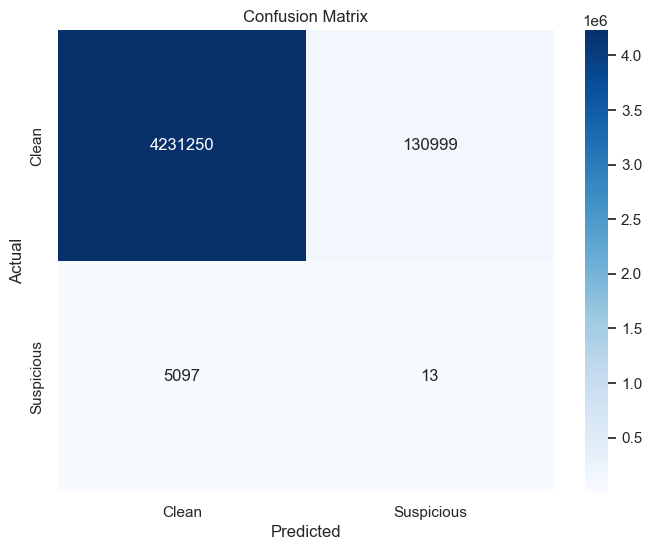

In [6]:
cm = confusion_matrix(df_results['is_laundering'], df_results['is_flagged'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Clean', 'Suspicious'], 
            yticklabels=['Clean', 'Suspicious'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 6. Precision-Recall Curve

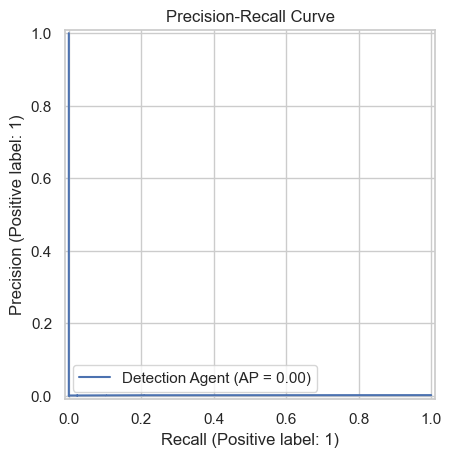

In [7]:
pd_display = PrecisionRecallDisplay.from_predictions(
    df_results['is_laundering'], df_results['anomaly_score'] * -1, name="Detection Agent"
)
plt.title("Precision-Recall Curve")
plt.show()

## 7. Anomaly Score Distribution

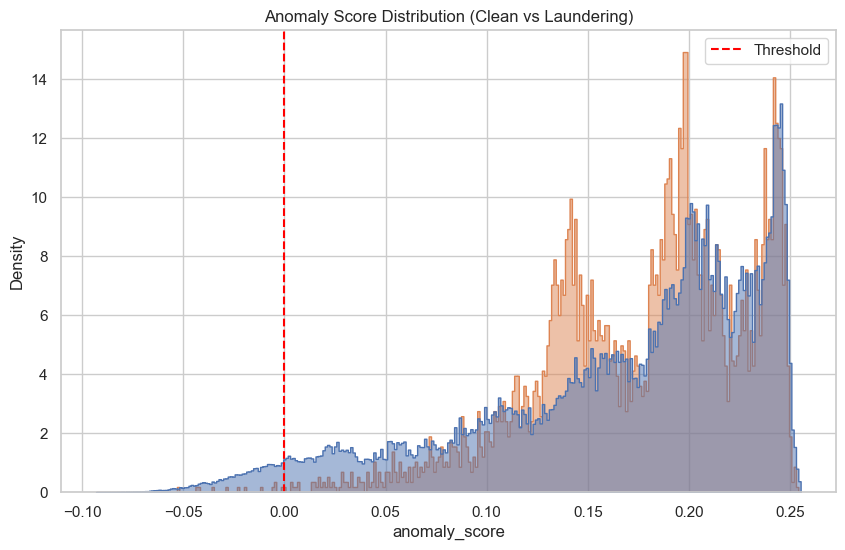

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_results, x='anomaly_score', hue='is_laundering', element="step", stat="density", common_norm=False, alpha=0.5)
plt.title("Anomaly Score Distribution (Clean vs Laundering)")
plt.axvline(x=agent.flag_threshold, color='red', linestyle='--', label='Threshold')
plt.legend()
plt.show()

## 8. Flag Reason Breakdown

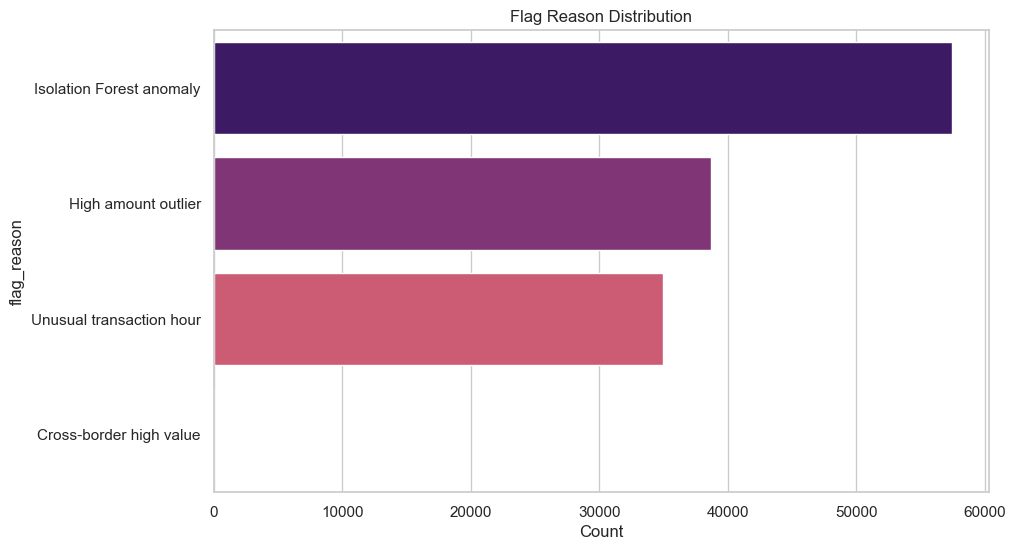

In [9]:
plt.figure(figsize=(10, 6))
reason_counts = flagged['flag_reason'].value_counts()
sns.barplot(x=reason_counts.values, y=reason_counts.index, hue=reason_counts.index, palette="magma")
plt.title("Flag Reason Distribution")
plt.xlabel("Count")
plt.show()

## 9. Save Results

In [10]:
os.makedirs("../data/processed", exist_ok=True)
df_results[df_results['is_flagged']].to_csv("../data/processed/flagged_transactions.csv", index=False)
df_results.to_csv("../data/processed/clean_transactions.csv", index=False)
print("Results saved to data/processed/")

Results saved to data/processed/
